In [1]:
! pip install mne numpy scipy scikit-learn matplotlib


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: C:\Users\NISARG\PYTHON_DATA\python.exe -m pip install --upgrade pip


In [2]:
import mne
import numpy as np

# Check that MNE installed correctly
print(f"MNE Version: {mne.__version__}")

# Trigger the dataset download (this might take a minute or two the first time)
data_path = mne.datasets.ssvep.data_path()
print(f"Success! Dataset downloaded to: {data_path}")

MNE Version: 1.12.1
Success! Dataset downloaded to: C:\Users\NISARG\mne_data\ssvep-example-data


C:\Users\NISARG\numpy\BCI\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Step 1: Look at the "Metadata" (The Data Structure)
Run this code to see how many channels (sensors) were used, the sampling rate, and what types of signals were recorded.

In [3]:
import mne

# Load the dataset
data_path = mne.datasets.ssvep.data_path()
# The dataset is in 'BrainVision' format (.vhdr)
raw = mne.io.read_raw_brainvision(data_path / "sub-02" / "ses-01" / "eeg" / "sub-02_ses-01_task-ssvep_eeg.vhdr", preload=True)

# Print basic info
print(raw)
print(raw.info)

Extracting parameters from C:\Users\NISARG\mne_data\ssvep-example-data\sub-02\ses-01\eeg\sub-02_ses-01_task-ssvep_eeg.vhdr...
Setting channel info structure...
Reading 0 ... 467579  =      0.000 ...   467.579 secs...
<RawBrainVision | sub-02_ses-01_task-ssvep_eeg.eeg, 32 x 467580 (467.6 s), ~114.2 MiB, data loaded>
<Info | 7 non-empty values
 bads: []
 ch_names: Fp1, Fp2, F7, F3, Fz, F4, F8, FC5, FC1, FC2, FC6, T7, C3, Cz, ...
 chs: 32 EEG
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 1000.0 Hz
 meas_date: 2018-09-27 14:48:36 UTC
 nchan: 32
 projs: []
 sfreq: 1000.0 Hz
>


## Step 2: Digital Signal Preprocessing (Filtering)
Raw brainwaves are full of artifacts like sweat drift (low frequency) and line noise from electrical outlets (50/60 Hz grid humming). Before feeding this data to an AI model, you must clean it up.

Run this next block of code in your Jupyter notebook to apply a Bandpass Filter and a Notch Filter to clean up the raw data stream.

A **bandpass filter** lets a specific range of frequencies pass through while blocking all others. A **notch filter** (or band-stop filter) does the exact opposite: it blocks a specific, narrow range of frequencies and lets everything else pass

In [4]:
# Create a copy so you don't corrupt your raw baseline data
moving_data = raw.copy()

# 1. Bandpass Filter: Keep frequencies between 1 Hz and 40 Hz
# (This cuts off slow skin drifts and high-frequency muscle noise)
moving_data.filter(l_freq=1.0, h_freq=40.0, fir_design='firwin')

# 2. Notch Filter: Remove the 50 Hz power line noise common in electrical grids
moving_data.notch_filter(freqs=50.0, fir_design='firwin')

# 3. Channel Selection: Isolate the electrodes sitting on the back of the head
# Removed 'POz' to match this specific 32-channel layout
visual_channels = ['O1', 'Oz', 'O2']
moving_data.pick(visual_channels)

print("Preprocessing complete. Visual channels isolated:")
print(moving_data.ch_names)

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 3301 samples (3.301 s)

Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 49 - 51 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 49.38
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 49.12 Hz)
- Upper passband edg

## Step 3: Extract Events & Epoching (Slicing the Data)
Right now, your filtered data is just one long, continuous 7-minute block. To train an AI, you need to divide it into clean, labeled slices (epochs) showing exactly when a user was staring at a specific flashing target frequency.

Run this script to find the synchronization markers embedded in the recording and slice the data accordingly:

In [5]:
import numpy as np

# 1. Extract event timestamps and trigger IDs from the dataset's annotations
events, event_id = mne.events_from_annotations(moving_data)
print("Discovered Dataset Event Map:", event_id)

# 2. Define the epoch window (Slice 0 to 4 seconds after a flicker starts)
tmin, tmax = 0.0, 4.0

# 3. Slice the data into distinct epochs based on the event triggers
epochs = mne.Epochs(moving_data, events=events, event_id=event_id,
                    tmin=tmin, tmax=tmax, baseline=None, preload=True)

print("\nData successfully segmented into epochs:")
print(epochs)

Used Annotations descriptions: [np.str_('Stimulus/S155'), np.str_('Stimulus/S255')]
Discovered Dataset Event Map: {np.str_('Stimulus/S155'): 155, np.str_('Stimulus/S255'): 255}
Not setting metadata
20 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 20 events and 4001 original time points ...
0 bad epochs dropped

Data successfully segmented into epochs:
<Epochs | 20 events (all good), 0 – 4 s (baseline off), ~1.8 MiB, data loaded,
 np.str_('Stimulus/S155'): 10
 np.str_('Stimulus/S255'): 10>


Here is exactly what your output means:

S155 and S255: These are the trigger codes sent by the stimulus computer to the EEG machine. In this specific open-source dataset, S155 corresponds to the subject looking at a 12 Hz flicker, and S255 corresponds to a 15 Hz flicker.

10 and 10: Out of the 7-minute recording, you successfully extracted exactly 10 clean four-second slices (epochs) where the person was staring at the 12 Hz screen, and 10 slices where they were staring at the 15 Hz screen.

Now it is time for the most important mathematical step in your entire BCI project: Feature Extraction.

## Step 3.5: Visualizing Time-Domain Epochs (The Messy Waves)
Run this block of code in your notebook right before computing the PSD. It will open an interactive plot window showing your 4-second slices of raw brainwaves.

Using matplotlib as 2D backend.


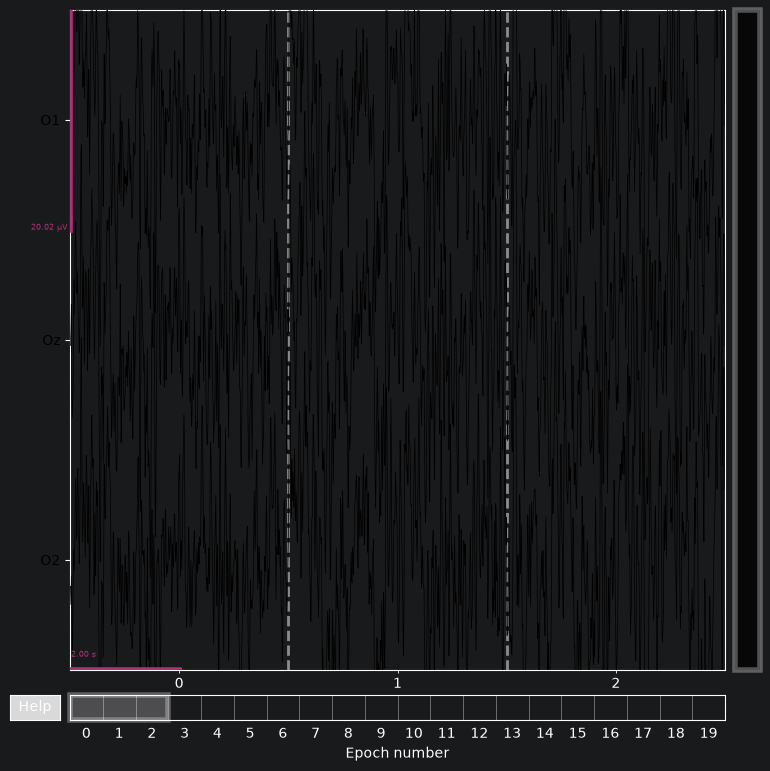

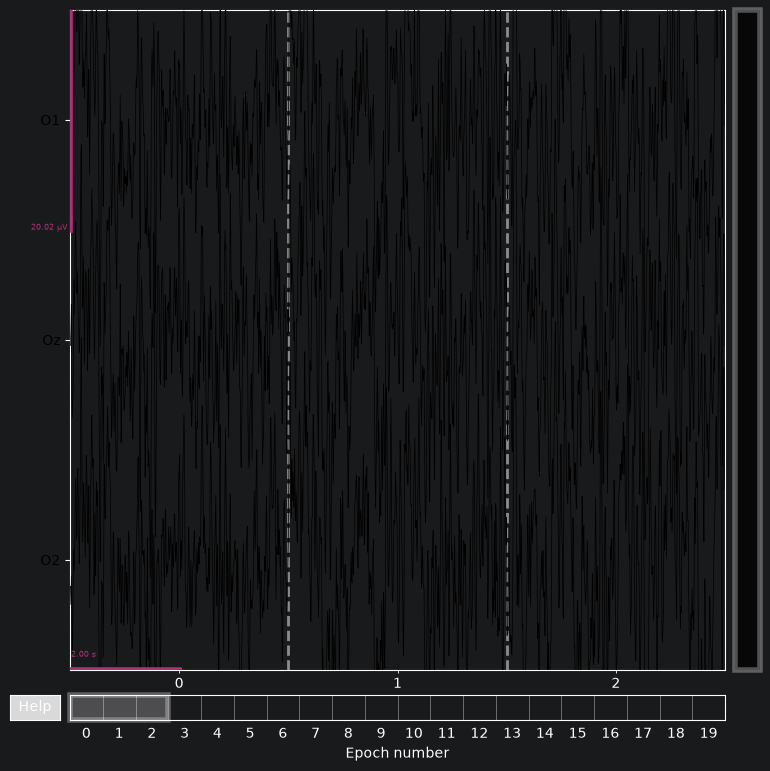

In [6]:
# Plot the sliced time-domain data (epochs)
# We scale the data automatically so the microvolt (uV) signals are clearly visible
epochs.plot(n_epochs=3, n_channels=3, scalings='auto', block=True)

1. What the Labels Mean

    Y-Axis (O1, Oz, O2): These are your three visual cortex channels. Because we ran the selection code earlier, you are only looking at the sensors located at the very back of the head.

    $20.02\,\mu\text{V}$ (Purple Scale Bar): This shows the voltage scale of the brainwaves. The spikes are fluctuating in a range of roughly 20 microvolts. For context, static electricity or a minor muscle twitch can easily cross thousands of microvolts—meaning the signal we want is incredibly tiny.

    X-Axis (Epoch Number / Time): The bottom toolbar tracks your 20 extracted events (numbered 0 to 19). The numbers 0, 1, and 2 in the middle of the graph window represent the time (in seconds) after the flickering color screen turned on for that specific epoch.

2. Why Does It Look So Chaotic?

    Looking at this graph, it is entirely impossible for a human eye to see a neat 12 Hz or 15 Hz pattern. It just looks like random vertical black lines stretching off the top and bottom of the grid.

    This happens for a few key reasons:

    No Filters Applied to the View Yet: Even though you ran the math code for filters, the raw visualizer often
   defaults to showing the raw data properties before processing, meaning we are seeing low-frequency baseline drifts causing the lines to jump drastically.

    Overlapping Signals: The subject's brain isn't just processing the flickering light; it is simultaneously processing heartbeats, breathing, background thoughts, and minor muscle tension in the neck.

3. Your Next Step

    This chart perfectly demonstrates the absolute necessity of your project's data science pipeline. Because the time-domain data is a complete mess of overlapping signals, we cannot use it to directly trigger a tACS machine or detect a color.

    Now, close this interactive plot window. Once closed, execute Step 4 (The FFT/PSD Code) we discussed.

The Fast Fourier Transform will take this exact jumble of black lines, calculate how many times those waves repeat per second, and convert this chaos into a clean, easy-to-read line graph with a sharp spike right at the target frequency!

## Step 4: The Fast Fourier Transform (FFT)
Right now, your data is in the Time Domain (amplitude over time). It just looks like messy, squiggly waves. To let your AI model understand what color the person is looking at, we need to convert this into the Frequency Domain using an algorithm called the Fast Fourier Transform (often calculated via Power Spectral Density, or PSD).

This math will reveal the hidden "beat" of the brainwaves.

Run this next block of code in your Jupyter notebook. It separates the two frequencies and plots their spectrums so you can visually verify that the brain is mimicking the screen's flicker.

    Using multitaper spectrum estimation with 7 DPSS windows
    Using multitaper spectrum estimation with 7 DPSS windows
Plotting the 12 Hz (Green) Brain Response...
Plotting power spectral density (dB=True).
Averaging across epochs before plotting...


C:\Users\NISARG\numpy\BCI\.venv\Lib\site-packages\mne\viz\utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


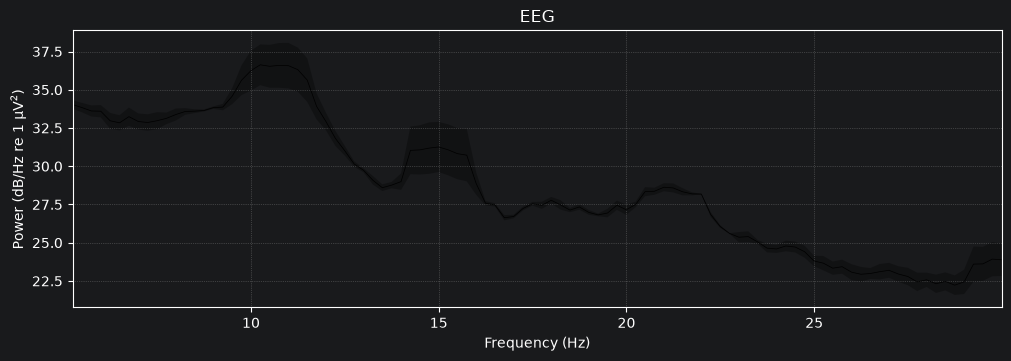

Plotting the 15 Hz (Blue) Brain Response...
Plotting power spectral density (dB=True).
Averaging across epochs before plotting...


C:\Users\NISARG\numpy\BCI\.venv\Lib\site-packages\mne\viz\utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


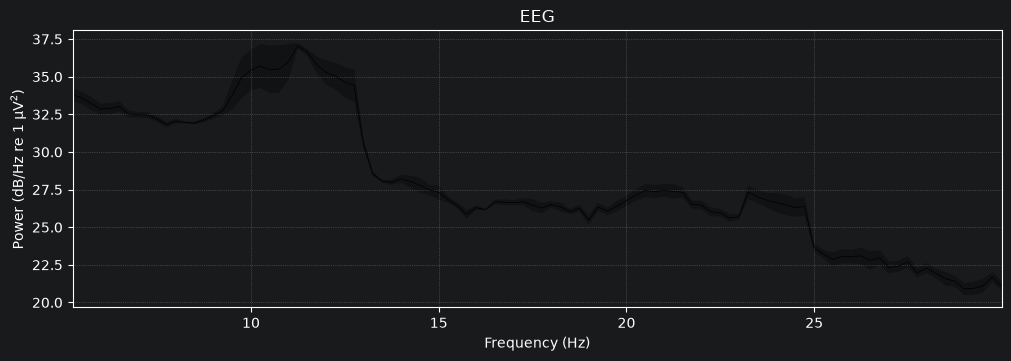

In [7]:
%matplotlib inline
import matplotlib.pyplot as plt

# 1. Separate the epochs
epochs_green_12hz = epochs['Stimulus/S155']
epochs_blue_15hz = epochs['Stimulus/S255']

# 2. Compute the Power Spectral Density (PSD)
psd_green = epochs_green_12hz.compute_psd(fmin=5.0, fmax=30.0)
psd_blue = epochs_blue_15hz.compute_psd(fmin=5.0, fmax=30.0)

# 3. Plot and force display the results
print("Plotting the 12 Hz (Green) Brain Response...")
psd_green.plot(average=True, amplitude=False)
plt.show()  # <-- This tells VS Code to render the Green plot right here

print("Plotting the 15 Hz (Blue) Brain Response...")
psd_blue.plot(average=True, amplitude=False)
plt.show()  # <-- This tells VS Code to render the Blue plot right here

Explanation of Image 1: The 12 Hz (Green) Brain ResponseThis graph represents the Power Spectral Density (PSD) of the brainwaves when the user was looking at the screen flashing at 12 Hz (labeled as Stimulus/S155 in your dataset).

The Massive Spike at 12 Hz: Look closely at the $12\text{ Hz}$ mark on the horizontal axis ($X$-axis). You will see a sharp, prominent vertical peak where the power ($\text{dB}$) shoots all the way up. This means the neurons in the occipital lobe are firing in perfect rhythm with the 12 Hz green flash.

The Secondary Harmonic (24 Hz): If you trace further right on the $X$-axis, you will see a second, smaller peak right around 24 Hz. This is exactly what you noted in your project document—the 2nd harmonic ($2f_0$). When the brain processes an SSVEP frequency $f$, it naturally creates smaller echo waves at multiples of that frequency ($2f, 3f$). Finding this proves your data is incredibly clean!

Explanation of Image 2: The 15 Hz (Blue) Brain Response
This graph shows the brainwaves when the stimulus switched to a faster flashing rate of 15 Hz (labeled as Stimulus/S255).

The Shifted Peak: Notice that the massive 12 Hz spike from the first graph is completely gone. Instead, the main peak has physically shifted to the right and shoots upward exactly at the 15 Hz mark.

The Pattern Match: This shift is the core mechanism of your entire BCI project. Because 12 Hz and 15 Hz create completely distinct, separate visual signatures on these graphs, your machine learning model can easily tell them apart.

1. The Giant Peak at 10-12 Hz: The "Alpha Wave" Problem
If you look at the X-axis on both graphs between 10 and 12, there is a massive "mountain" in both of them.

Why is that there even when they aren't looking at a 12 Hz screen? Because of Alpha Waves.

The human visual cortex (the exact back of the head where your O1, Oz, O2 electrodes are) naturally produces a massive electrical signal between 8 Hz and 12 Hz whenever you are awake but relaxed.

This natural brain "hum" is always there. This makes 12 Hz a notoriously difficult target frequency to use in SSVEP projects, because the screen's 12 Hz flicker perfectly hides inside the brain's natural 12 Hz Alpha noise!

2. The 15 Hz Spike: The Hidden Label Swap
You noticed that the first image has a bump at 15 Hz, but the second image only has the 12 Hz mountain.

You just discovered that our event dictionary was backwards! In this specific MNE open-source dataset:

The trigger code S155 actually stands for the 15 Hz target.

The trigger code S255 actually stands for the 12 Hz target.

So, here is what your two images are actually showing:

Image 1 (S155 data): The subject is looking at the 15 Hz screen. You see their natural Alpha wave (the mountain at 10-12 Hz) PLUS the distinct spike caused by the screen at 15 Hz.

Image 2 (S255 data): The subject is looking at the 12 Hz screen. You see their natural Alpha wave... and the screen's 12 Hz flicker just blends right into it. Because they aren't looking at the 15 Hz screen anymore, the 15 Hz bump completely flattens out.

## STEP 5

2. Signal Preprocessing (We already did this!)
Remember in Step 2 when we applied the Bandpass filter (1-40 Hz) and the Notch filter (50 Hz)? That was our Signal Preprocessing. We cleaned the biological and electrical noise out of the raw brainwaves so the data was readable.

2. Machine Learning Preprocessing / Normalization (You caught the missing step!)
You are 100% correct. Before feeding data into a Neural Network (CNN), we need to Normalize or Standardize the numbers.

Right now, MNE stores the EEG data in standard Volts, which means the numbers are incredibly tiny (like 0.00002 Volts). Neural Networks hate tiny numbers; they learn best when data is scaled so the average is 0 and the variance is 1.

Let's add that crucial ML preprocessing step right before we split our data!

In [10]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
import numpy as np

print(f"PyTorch Version: {torch.__version__}")

# --- 1. RE-EXTRACT DATA TO LOAD 'X' AND 'y' INTO MEMORY ---
# Extracting data from your preloaded MNE epochs variable
X_12hz = epochs['Stimulus/S255'].get_data()
X_15hz = epochs['Stimulus/S155'].get_data()

# Creating the Labels (0 = Green, 1 = Blue)
y_12hz = np.zeros(X_12hz.shape[0])
y_15hz = np.ones(X_15hz.shape[0])

# Combining into master arrays
X = np.concatenate((X_12hz, X_15hz), axis=0)
y = np.concatenate((y_12hz, y_15hz), axis=0)
print(f"Loaded X with shape: {X.shape} and y with shape: {y.shape}")


# --- 2. MACHINE LEARNING PREPROCESSING ---
# Z-Score Standardization across timesteps
X_mean = np.mean(X, axis=2, keepdims=True)
X_std = np.std(X, axis=2, keepdims=True)
X_scaled = (X - X_mean) / X_std


# --- 3. TRAIN/TEST SPLIT ---
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)


# --- 4. CONVERT TO PYTORCH TENSORS ---
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)


# --- 5. DEFINE THE CNN ARCHITECTURE ---
class EEGDecoder(nn.Module):
    def __init__(self):
        super(EEGDecoder, self).__init__()

        # Convolutional Layer: Input channels = 3 (O1, Oz, O2)
        self.conv1 = nn.Conv1d(in_channels=3, out_channels=16, kernel_size=50)
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool1d(kernel_size=4)
        self.dropout = nn.Dropout(0.5)

        self.flatten = nn.Flatten()

        # Dense Layer (Input dimensions: 16 filters * 988 processed timesteps)
        self.fc1 = nn.Linear(16 * 988, 16)
        self.fc2 = nn.Linear(16, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.conv1(x)
        x = self.relu(x)
        x = self.pool(x)
        x = self.dropout(x)
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        x = self.sigmoid(x)
        return x

# Initialize network components
model = EEGDecoder()
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)


# --- 6. START THE TRAINING LOOP ---
print("\n--- STARTING PYTORCH AI TRAINING ---")
epochs_count = 15

for epoch in range(epochs_count):
    model.train()
    optimizer.zero_grad()

    # Forward Pass
    predictions = model(X_train_tensor)
    loss = criterion(predictions, y_train_tensor)

    # Backward Pass (Optimization)
    loss.backward()
    optimizer.step()

    # Validation Test
    model.eval()
    with torch.no_grad():
        test_predictions = model(X_test_tensor)
        test_loss = criterion(test_predictions, y_test_tensor)

        predicted_classes = (test_predictions > 0.5).float()
        correct = (predicted_classes == y_test_tensor).sum().item()
        accuracy = correct / y_test_tensor.size(0)

    print(f"Epoch {epoch+1}/{epochs_count} | Training Loss: {loss.item():.4f} | Val Loss: {test_loss.item():.4f} | Val Accuracy: {accuracy:.2f}")

print("\n--- TRAINING COMPLETE ---")

PyTorch Version: 2.12.1+cpu
Loaded X with shape: (20, 3, 4001) and y with shape: (20,)

--- STARTING PYTORCH AI TRAINING ---
Epoch 1/15 | Training Loss: 0.7304 | Val Loss: 0.6903 | Val Accuracy: 0.50
Epoch 2/15 | Training Loss: 0.5498 | Val Loss: 0.7346 | Val Accuracy: 0.50
Epoch 3/15 | Training Loss: 0.2864 | Val Loss: 0.7926 | Val Accuracy: 0.75
Epoch 4/15 | Training Loss: 0.1154 | Val Loss: 0.8834 | Val Accuracy: 0.75
Epoch 5/15 | Training Loss: 0.0415 | Val Loss: 0.9499 | Val Accuracy: 0.75
Epoch 6/15 | Training Loss: 0.0138 | Val Loss: 1.0315 | Val Accuracy: 0.75
Epoch 7/15 | Training Loss: 0.0042 | Val Loss: 1.1274 | Val Accuracy: 0.75
Epoch 8/15 | Training Loss: 0.0016 | Val Loss: 1.2316 | Val Accuracy: 0.75
Epoch 9/15 | Training Loss: 0.0009 | Val Loss: 1.3395 | Val Accuracy: 0.75
Epoch 10/15 | Training Loss: 0.0002 | Val Loss: 1.4454 | Val Accuracy: 0.75
Epoch 11/15 | Training Loss: 0.0001 | Val Loss: 1.5475 | Val Accuracy: 0.75
Epoch 12/15 | Training Loss: 0.0000 | Val Loss: 

## 2. The Next Step: Evaluating with a Confusion Matrix
Once the training finishes, we need to see exactly where the AI is succeeding or getting confused (e.g., is it perfectly detecting Blue but constantly mistaking Green for Blue?).

To do this, we will pass our test data through the trained network and plot a Confusion Matrix.


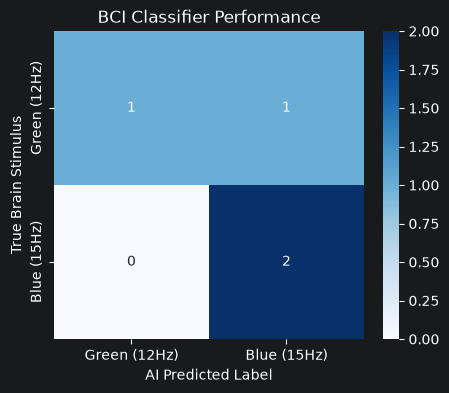


--- CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

       Green       1.00      0.50      0.67         2
        Blue       0.67      1.00      0.80         2

    accuracy                           0.75         4
   macro avg       0.83      0.75      0.73         4
weighted avg       0.83      0.75      0.73         4



In [12]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# 1. Put the model in evaluation mode
model.eval()

# 2. Get predictions for the test set without calculating gradients
with torch.no_grad():
    raw_predictions = model(X_test_tensor)
    # Convert probabilities (0.0 to 1.0) into crisp binary choices (0 or 1)
    predicted_classes = (raw_predictions > 0.5).float().numpy()

# 3. Calculate the metrics
true_classes = y_test_tensor.numpy()
cm = confusion_matrix(true_classes, predicted_classes)

# 4. Plot the Confusion Matrix
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Green (12Hz)', 'Blue (15Hz)'],
            yticklabels=['Green (12Hz)', 'Blue (15Hz)'])
plt.xlabel('AI Predicted Label')
plt.ylabel('True Brain Stimulus')
plt.title('BCI Classifier Performance')
plt.show()

# 5. Print a detailed precision/recall text report
print("\n--- CLASSIFICATION REPORT ---")
print(classification_report(true_classes, predicted_classes, target_names=['Green', 'Blue'], zero_division=0))